In [57]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
RAW_DIR = "/content/drive/MyDrive/AI_TraceFinder/raw_selected"
OUT_DIR = "/content/drive/MyDrive/AI_TraceFinder/milestone1_preprocessed"


MILESTONE 2

In [ ]:
!apt-get install poppler-utils
!pip install pdf2image pillow  //convert tif and pdf to png



Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 1 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12 [186 kB]
Fetched 186 kB in 1s (202 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 117528 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.12) ...
Setting up poppler-utils (22.02.0-2ubuntu0.12) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
import os
import cv2
import numpy as np
from pdf2image import convert_from_path
from PIL import Image

SRC_DIR = "/content/drive/MyDrive/AI_TraceFinder/milestone1_preprocessed"
DST_DIR = "/content/drive/MyDrive/AI_TraceFinder/milestone1_png"

os.makedirs(DST_DIR, exist_ok=True)

def read_tiff_safe(path):
    # Try OpenCV first
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        return img

    # Fallback to PIL
    try:
        img = Image.open(path)
        img = img.convert("L")
        return np.array(img)
    except:
        return None

for scanner in os.listdir(SRC_DIR):
    in_path = os.path.join(SRC_DIR, scanner)
    out_path = os.path.join(DST_DIR, scanner)
    os.makedirs(out_path, exist_ok=True)

    for file in os.listdir(in_path):
        file_path = os.path.join(in_path, file)

        # ---- PDF ----
        if file.lower().endswith(".pdf"):
            try:
                pages = convert_from_path(file_path, dpi=300)
                for i, page in enumerate(pages):
                    img = np.array(page.convert("L"))
                    cv2.imwrite(f"{out_path}/{file}_{i}.png", img)
            except:
                print("Skipped PDF:", file)

        # ---- TIFF ----
        elif file.lower().endswith((".tif", ".tiff")):
            img = read_tiff_safe(file_path)
            if img is not None:
                cv2.imwrite(f"{out_path}/{file}.png", img)
            else:
                print("Skipped TIFF:", file)

print("Conversion completed with safe fallback ✅")


Conversion completed with safe fallback ✅


In [ ]:
import os

BASE = "/content/drive/MyDrive/AI_TraceFinder/milestone1_png"
for s in os.listdir(BASE):
    print(s, "→", len(os.listdir(os.path.join(BASE, s))))


HP → 200
EpsonV550 → 200
Canon9000-1 → 200


In [ ]:
import os
import cv2
import numpy as np
from skimage.feature import local_binary_pattern
from scipy.fftpack import fft2

DATA_DIR = "/content/drive/MyDrive/AI_TraceFinder/milestone1_png"

X, y = [], []

def extract_features(img):
    feats = []

    # Noise statistics
    feats.append(np.mean(img))
    feats.append(np.std(img))

    # LBP
    lbp = local_binary_pattern(img, P=8, R=1, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0,10), density=True)
    feats.extend(hist)

    # FFT
    fft_img = np.abs(fft2(img))
    feats.append(np.mean(fft_img))
    feats.append(np.std(fft_img))

    return feats

for label, scanner in enumerate(sorted(os.listdir(DATA_DIR))):
    scanner_path = os.path.join(DATA_DIR, scanner)
    for file in os.listdir(scanner_path):
        img_path = os.path.join(scanner_path, file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        feats = extract_features(img)
        X.append(feats)
        y.append(label)

X = np.array(X)
y = np.array(y)

print("Feature matrix shape:", X.shape)


Feature matrix shape: (600, 14)


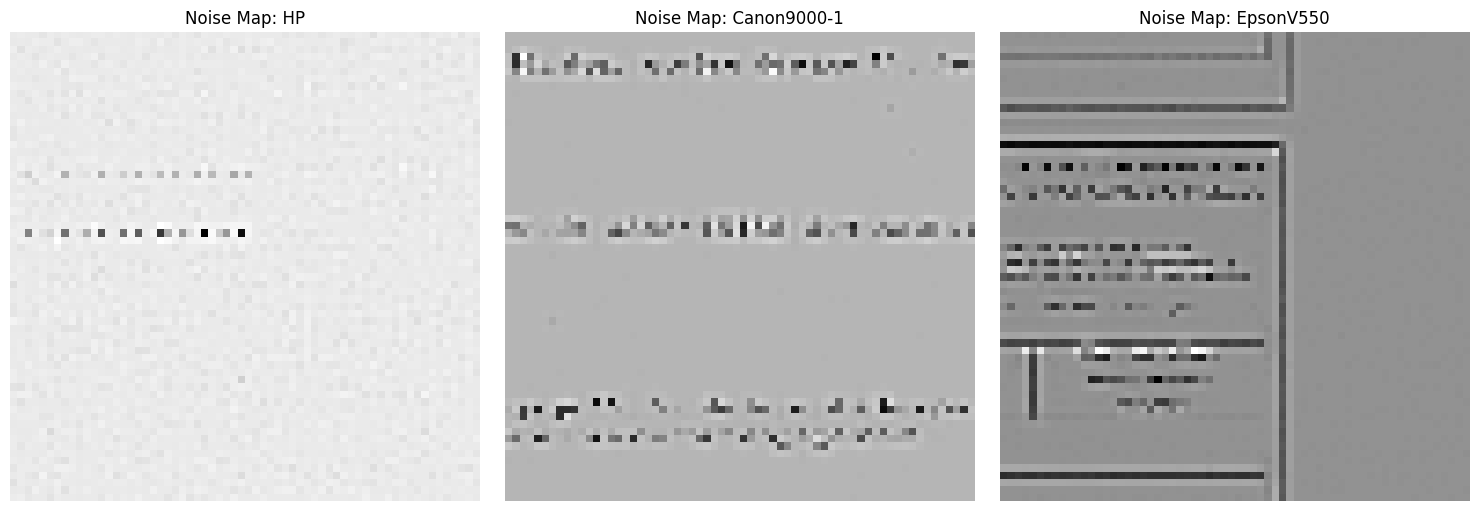

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter

def plot_noise_maps(X, y, class_names):
    plt.figure(figsize=(15, 5))
    for i in range(3): # Take one sample from each scanner
        idx = np.where(y == i)[0][0]
        img = X[idx].squeeze()

        # Extract noise: Original - Denoised
        noise = img - median_filter(img, size=3)

        plt.subplot(1, 3, i+1)
        plt.imshow(noise, cmap='gray')
        plt.title(f"Noise Map: {class_names[i]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_noise_maps(X_val, y_val, SCANNERS)

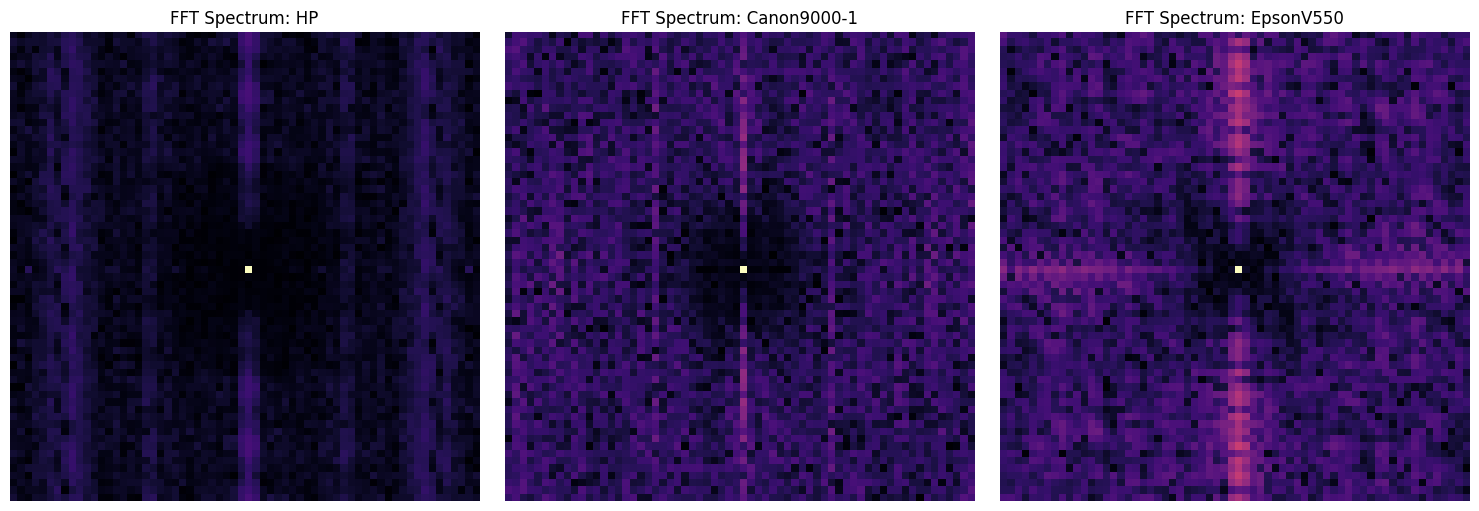

In [103]:
def plot_fft_spectrum(X, y, class_names):
    plt.figure(figsize=(15, 5))
    for i in range(3):
        idx = np.where(y == i)[0][0]
        img = X[idx].squeeze()

        # Calculate 2D FFT
        f_transform = np.fft.fft2(img)
        f_shift = np.fft.fftshift(f_transform) # Center the low frequencies
        magnitude_spectrum = 20 * np.log(np.abs(f_shift) + 1) # Log scale for visibility

        plt.subplot(1, 3, i+1)
        plt.imshow(magnitude_spectrum, cmap='magma')
        plt.title(f"FFT Spectrum: {class_names[i]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_fft_spectrum(X_val, y_val, SCANNERS)

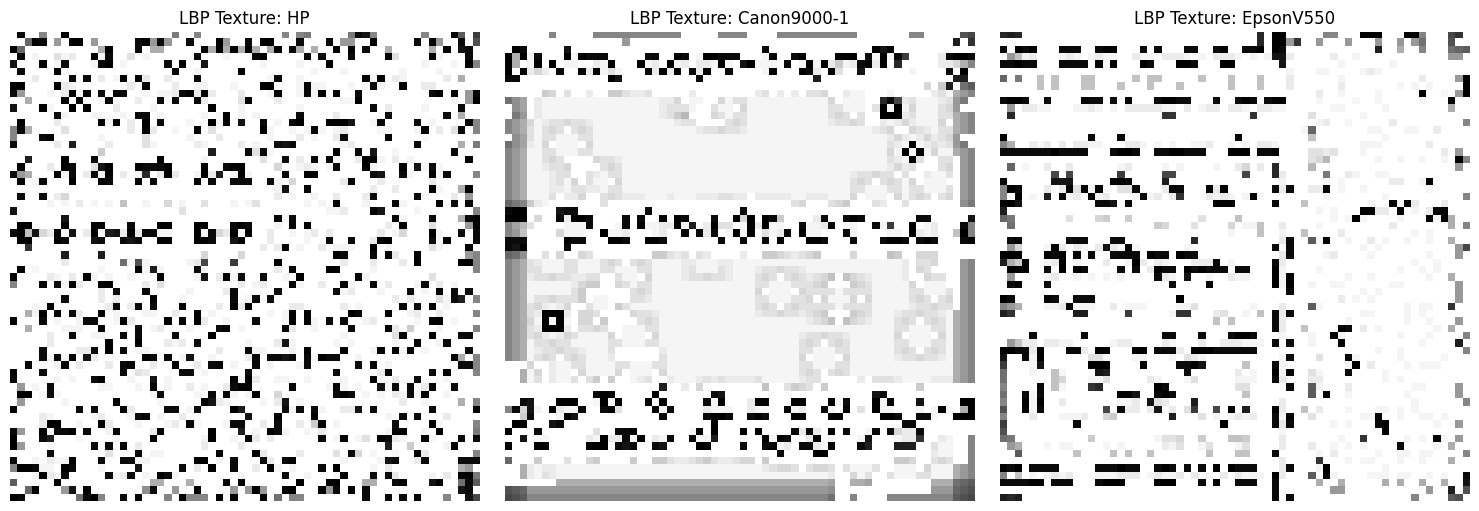

In [104]:
from skimage.feature import local_binary_pattern

def plot_lbp(X, y, class_names):
    # LBP Parameters
    radius = 3
    n_points = 8 * radius

    plt.figure(figsize=(15, 5))
    for i in range(3):
        idx = np.where(y == i)[0][0]
        img = (X[idx].squeeze() * 255).astype('uint8') # Ensure uint8

        lbp = local_binary_pattern(img, n_points, radius, method='uniform')

        plt.subplot(1, 3, i+1)
        plt.imshow(lbp, cmap='gray')
        plt.title(f"LBP Texture: {class_names[i]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_lbp(X_val, y_val, SCANNERS)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale'))
])

svm_pipeline.fit(X_train, y_train)

y_pred_svm = svm_pipeline.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))



SVM Accuracy: 0.9916666666666667
Confusion Matrix:
 [[39  1  0]
 [ 0 40  0]
 [ 0  0 40]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        40
           1       0.98      1.00      0.99        40
           2       1.00      1.00      1.00        40

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.9916666666666667
Confusion Matrix:
 [[39  1  0]
 [ 0 40  0]
 [ 0  0 40]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        40
           1       0.98      1.00      0.99        40
           2       1.00      1.00      1.00        40

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120



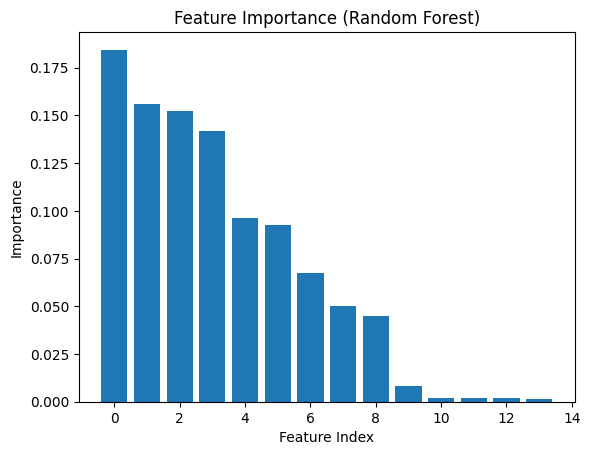

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure()
plt.bar(range(len(importances)), importances[indices])
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.show()


In [ ]:
import hashlib
import os

def file_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = {}
duplicates = 0

for scanner in os.listdir(DATA_DIR):
    for file in os.listdir(os.path.join(DATA_DIR, scanner)):
        h = file_hash(os.path.join(DATA_DIR, scanner, file))
        if h in hashes:
            duplicates += 1
        hashes[h] = file

print("Duplicate images found:", duplicates)


Duplicate images found: 0
